## This notebook trains the classical model on the datasets. The workflow will be standardised into a function after ensuring it works on MRPC soo that it can be applied on PAWS and QQP without rewriting the code blocks again. The accuracy will me measured and stored for final performance comparisons

In [3]:
#Importing required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import joblib

import sys
import os

sys.path.append(os.path.abspath(".."))

from src.utils import *

# 1. MRPC

In [4]:
#Load the processed datasets
train = pd.read_csv(
    "../datasets/processed/classical/mrpc_train.csv"
)

validation = pd.read_csv(
    "../datasets/processed/classical/mrpc_validation.csv"
)

test = pd.read_csv(
    "../datasets/processed/classical/mrpc_test.csv"
)

In [5]:
#Combine Sentence Pairs
def combine_sentences(df):
    return (
        df["sentence1"]
        + " [SEP] "
        + df["sentence2"]
    )

In [6]:
X_train = combine_sentences(train)
X_validation = combine_sentences(validation)
X_test = combine_sentences(test)

y_train = train["label"]
y_validation = validation["label"]
y_test = test["label"]

In [7]:
#Define the TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

In [8]:
X_train_vector = vectorizer.fit_transform(
    X_train
)

X_validation_vector = vectorizer.transform(
    X_validation
)

X_test_vector = vectorizer.transform(
    X_test
)

In [9]:
#Training a Logistic Regression model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [10]:
model.fit(
    X_train_vector,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [11]:
#Predictions
validation_predictions = model.predict(
    X_validation_vector
)

validation_probabilities = model.predict_proba(
    X_validation_vector
)[:,1]

In [12]:
#Evaluation
accuracy = accuracy_score(
    y_validation,
    validation_predictions
)

precision = precision_score(
    y_validation,
    validation_predictions
)

recall = recall_score(
    y_validation,
    validation_predictions
)

f1 = f1_score(
    y_validation,
    validation_predictions
)

roc_auc = roc_auc_score(
    y_validation,
    validation_probabilities
)

In [13]:
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.7279
Precision: 0.7234
Recall   : 0.9749
F1 Score : 0.8305
ROC-AUC  : 0.6759


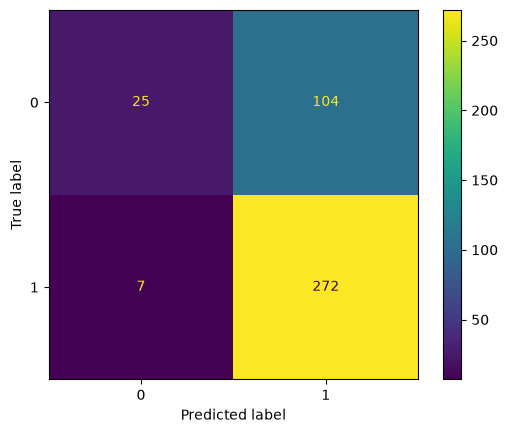

In [14]:
cm = confusion_matrix(
    y_validation,
    validation_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.savefig(
    "../results/plots/mrpc_confusion_matrix.png",
    dpi=300
)

plt.show()

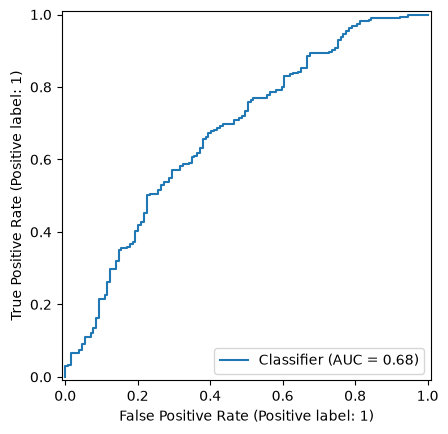

In [15]:
RocCurveDisplay.from_predictions(
    y_validation,
    validation_probabilities
)

plt.savefig(
    "../results/plots/mrpc_roc_curve.png",
    dpi=300
)

plt.show()

In [16]:
#Saving the results
metrics = pd.DataFrame({
    "Accuracy":[accuracy],
    "Precision":[precision],
    "Recall":[recall],
    "F1":[f1],
    "ROC_AUC":[roc_auc]
})

metrics.to_csv(
    "../results/metrics/mrpc_logreg_metrics.csv",
    index=False
)

In [18]:
#Saving the predictions
predictions = validation.copy()
predictions["prediction"] = validation_predictions
predictions["probability"] = validation_probabilities

predictions.to_csv(
    "../results/predictions/mrpc_predictions.csv",
    index=False
)

In [19]:
#Saving the model
Path("../models/classical").mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    vectorizer,
    "../models/classical/tfidf_vectorizer.pkl"
)

joblib.dump(
    model,
    "../models/classical/logistic_regression.pkl"
)

['../models/classical/logistic_regression.pkl']

In [20]:
#Error Analysis
errors = predictions[
    predictions["label"] != predictions["prediction"]
]

errors.head(20)

,sentence1,sentence2,label,idx,prediction,probability
1,magnarelli said racicot hated the iraqi regime...,"his wife said he was "" 100 percent behind geor...",0,18,1,0.649710
4,no dates have been set for the civil or the cr...,no dates have been set for the criminal or civ...,0,33,1,0.628857
6,while dioxin levels in the environment were up...,the institute said dioxin levels in the enviro...,0,54,1,0.701684
11,""" sanitation is poor ... there could be typhoi...",""" sanitation is poor , drinking water is gener...",0,83,1,0.699066
19,the pound also made progress against the dolla...,the british pound flexed its muscle against th...,0,175,1,0.514979
22,"the driver , eugene rogers , helped to remove ...","at the accident scene , the driver was "" cover...",0,222,1,0.683913
26,cooley said he expects muhammad will similarly...,lee boyd malvo will be called as a witness wed...,0,284,1,0.699723
30,"with these assets , funny cide has a solid cha...",funny cide is looking to become horse racing '...,0,334,1,0.749794
35,"bush wanted "" to see an aircraft landing the s...","on tuesday , before byrd 's speech , fleischer...",0,374,1,0.828424
36,"on monday the palestinian prime minister , mah...",palestinian prime minister mahmoud abbas must ...,0,375,1,0.715886


In [27]:
#Logging training time
import time

start_time = time.perf_counter()
model.fit(
    X_train_vector,
    y_train
)
end_time = time.perf_counter()

training_time = end_time - start_time

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.0364 seconds


In [29]:
#Logging inference time
start = time.perf_counter()
validation_predictions = model.predict(X_validation_vector)
validation_probabilities = model.predict_proba(X_validation_vector)[:, 1]
end = time.perf_counter()
inference_time = end - start
print(f"Inference Time: {inference_time:.4f} seconds")

Inference Time: 0.0023 seconds


In [30]:
#Logging the output
from datetime import date
metrics = {
    "Experiment ID": "EXP-001",
    "Date": date.today().isoformat(),
    "Phase": "Baseline",
    "Model": "Logistic Regression",
    "Dataset": "MRPC",
    "Train Split": len(train),
    "Validation Split": len(validation),
    "Test Split": len(test),
    "Batch Size": "N/A",
    "Learning Rate": "N/A",
    "Epochs": "N/A",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC-AUC": roc_auc,
    "BLEU": "N/A",
    "ROUGE": "N/A",
    "BERTScore": "N/A",
    "Train Time": training_time,
    "Inference Time": inference_time,
    "Notes": "TF-IDF (1,2)-gram baseline",
    "Status": "Completed"
}

log_experiment("../logs/experiments.xlsx", metrics)

ValueError: 'Experiment ID' is not a valid column name. Column names are from A to ZZZ